In [5]:
! pip install --upgrade pip


  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\Prince\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

ModuleNotFoundError: No module named 'tensorflow.keras'

In [29]:
data_dir = "C:/Users/Prince/Desktop/AI for Bhart/kidney-ai-backend\kidney-ct-scan-image"

normal_path = os.path.join(data_dir, "Normal")
tumor_path = os.path.join(data_dir, "Tumor")

In [30]:
normal_count = len(os.listdir(normal_path))
tumor_count = len(os.listdir(tumor_path))

print("Normal Images:", normal_count)
print("Tumor Images:", tumor_count)
print("Total Images:", normal_count + tumor_count)

Normal Images: 240
Tumor Images: 225
Total Images: 465


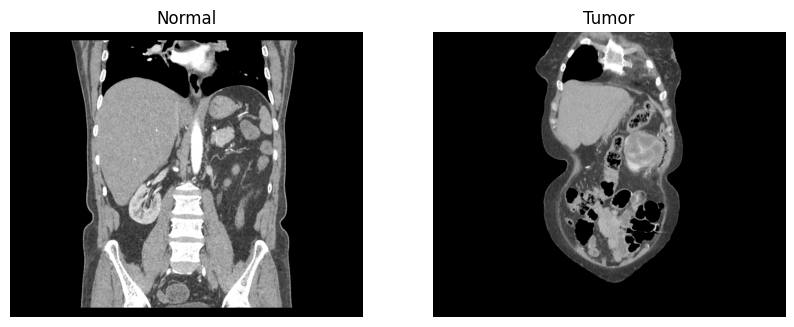

In [31]:
img1 = Image.open(os.path.join(normal_path, os.listdir(normal_path)[0]))
img2 = Image.open(os.path.join(tumor_path, os.listdir(tumor_path)[0]))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Normal")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Tumor")
plt.axis("off")

plt.show()

In [32]:
sizes = []

for folder in ["Normal", "Tumor"]:
    path = os.path.join(data_dir, folder)
    
    for file in os.listdir(path)[:10]:
        img = Image.open(os.path.join(path, file))
        sizes.append(img.size)

print(sizes)

[(755, 611), (755, 611), (755, 611), (512, 512), (755, 611), (755, 611), (755, 611), (755, 611), (755, 611), (755, 611), (768, 622), (768, 622), (768, 622), (768, 622), (768, 622), (768, 622), (768, 622), (768, 622), (768, 622), (512, 512)]


In [33]:
train_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_data.class_names
print("Classes:", class_names)

Found 465 files belonging to 2 classes.
Using 372 files for training.
Found 465 files belonging to 2 classes.
Using 93 files for validation.
Classes: ['Normal', 'Tumor']


In [34]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)

In [35]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
normalization_layer = layers.Rescaling(1./255)

In [37]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # Freeze initially

inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = normalization_layer(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential_1 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d_2  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization (Batch  (None, 1280)              5120

In [38]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 [==============================] - 38s 2s/step - loss: 0.2739 - accuracy: 0.8763 - val_loss: 0.1985 - val_accuracy: 0.9785
Epoch 2/10
12/12 [==============================] - 18s 2s/step - loss: 0.0301 - accuracy: 0.9892 - val_loss: 0.0893 - val_accuracy: 0.9892
Epoch 3/10
12/12 [==============================] - 19s 2s/step - loss: 0.0207 - accuracy: 0.9946 - val_loss: 0.0618 - val_accuracy: 0.9892
Epoch 4/10
12/12 [==============================] - 19s 2s/step - loss: 0.0173 - accuracy: 0.9973 - val_loss: 0.0610 - val_accuracy: 0.9892
Epoch 5/10
12/12 [==============================] - 19s 2s/step - loss: 0.0049 - accuracy: 1.0000 - val_loss: 0.0578 - val_accuracy: 0.9892
Epoch 6/10
12/12 [==============================] - 19s 2s/step - loss: 0.0057 - accuracy: 1.0000 - val_loss: 0.0548 - val_accuracy: 0.9892
Epoch 7/10
12/12 [==============================] - 19s 2s/step - loss: 0.0057 - accuracy: 0.9973 - val_loss: 0.0511 - val_accuracy: 0.9892
Epoch 8/10
12/12 [==

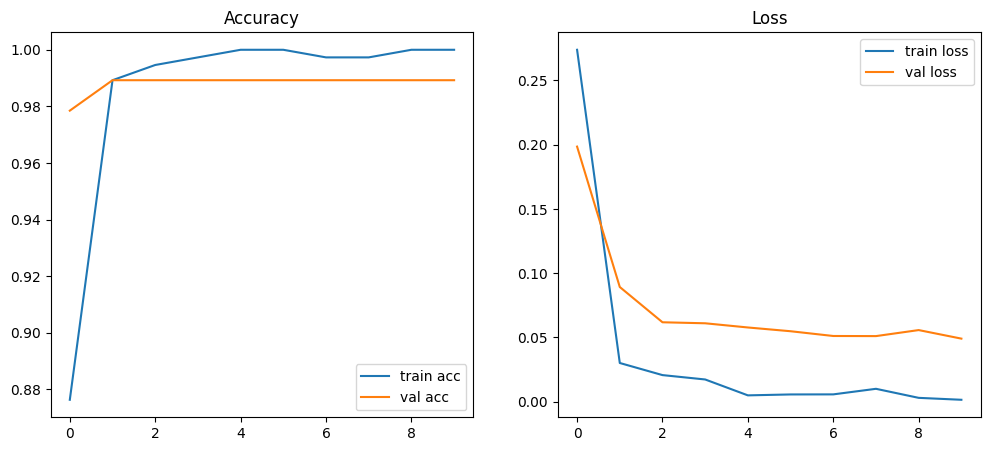

In [39]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")

plt.show()

In [40]:
base_model.trainable = True

# Unfreeze last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
12/12 [==============================] - 32s 2s/step - loss: 0.0048 - accuracy: 0.9973 - val_loss: 0.0402 - val_accuracy: 0.9892
Epoch 2/5
12/12 [==============================] - 22s 2s/step - loss: 0.0015 - accuracy: 1.0000 - val_loss: 0.0293 - val_accuracy: 0.9892
Epoch 3/5
12/12 [==============================] - 22s 2s/step - loss: 8.1069e-04 - accuracy: 1.0000 - val_loss: 0.0300 - val_accuracy: 0.9892
Epoch 4/5
12/12 [==============================] - 23s 2s/step - loss: 6.1840e-04 - accuracy: 1.0000 - val_loss: 0.0339 - val_accuracy: 0.9892
Epoch 5/5
12/12 [==============================] - 27s 2s/step - loss: 3.9013e-04 - accuracy: 1.0000 - val_loss: 0.0357 - val_accuracy: 0.9892


In [ ]:
model.save("kidney_model.keras")

1/1 [==============================] - 8s 8s/step
Actual: 1 Pred: 0.9996436
Actual: 0 Pred: 0.008223239
Actual: 1 Pred: 0.9948945
Actual: 0 Pred: 0.00015927965
Actual: 1 Pred: 0.9999687
Actual: 1 Pred: 0.046343442
Actual: 0 Pred: 0.00069245853
Actual: 1 Pred: 0.999914
Actual: 1 Pred: 0.9744722
Actual: 1 Pred: 0.9910261


In [45]:
pip show tensorflow

Name: tensorflowNote: you may need to restart the kernel to use updated packages.

Version: 2.13.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: c:\users\prince\appdata\local\programs\python\python310\lib\site-packages
Requires: tensorflow-intel
Required-by: 
